# Import

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import re
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold,StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, balanced_accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import matplotlib.cbook as cbook

import warnings
warnings.filterwarnings("ignore")

FILE_PATH = Path('/Users/francesco/Tesi/BC-ML4/dataset/cleaned')


TIPO_FOLD = "kfold"
BALANCE_TEST = True
TARGET_MAP = {
    "duke": "ER",
    "ambl": "ER [SII]",
    "duke_medsam": "ER",
    "ambl_medsam": "ER [SII]"
}

# Funzioni

In [2]:
def load_dataset(file_path, csv_name):
    """Carica il CSV"""
    df = pd.read_csv(file_path)

    # Informazioni base sul dataset_name
    print(f"  Shape: {df.shape}")
    print(f"  Colonne: {df.shape[1]}")
    print(f"  Righe: {df.shape[0]}")
    # Mostro solo le prime 5 righe
    print(df.head(5))

    if "Patient ID" not in df.columns:
        raise ValueError(f"{csv_name} - manca 'Patient ID'")
    return df.copy()

def select_target(df, target_col):
    """Verifica che il target sia valido"""
    
    # Evito di addestrare su colonne sbagliate
    if target_col not in df.columns:
        raise ValueError(f"Colonna '{target_col}' mancante")
    
    # Mostro valori PRIMA della selezione
    print(f"\n VALORI TARGET PRIMA DELLA PULIZIA:")
    print(f"  Tipo: {df[target_col].dtype}")
    print(f"  Valori unici: {sorted(df[target_col].dropna().unique())}")
    print(f"  NaN: {df[target_col].isna().sum()}")
    print(f"\n  Distribuzione:")
    print(df[target_col].value_counts(dropna=False))
    y = df[target_col]
    
    if y.nunique() < 2:
        raise ValueError(f"Target '{target_col}' ha una sola classe")
    
    # Statistiche più dettagliate
    print(f"\n Target selezionato:")
    print(f"  Classe 0: {(y==0).sum()} ({(y==0).sum()/len(y)*100:.1f}%)")
    print(f"  Classe 1: {(y==1).sum()} ({(y==1).sum()/len(y)*100:.1f}%)")
    
    return df, y


def build_features_and_groups(df, target_col, dataset_type):
    print(f"\n{'='*80}")
    print(f"COSTRUZIONE FEATURES E GROUPS")
    print(f"{'='*80}")
    
    # Serve per la StratifiedGroupKFold
    groups = df["Patient ID"].copy()
    
    
    # Colonne comuni da rimuovere
    base_drop_cols = [
        "Patient ID", 
        "lesion idx", 
        "tumor/benign",
        "Breast",
        target_col
    ]

    # Definsico gli altri target da cancellare in base al csv
    if "duke" in dataset_type:
        other_targets = ["GRADE", "isTN", "PR", "HER2"]
    elif "ambl" in dataset_type: 
        other_targets = ["PR [SII]", "HER2 [SII]"]
    else:
        raise ValueError(f"Dataset type '{dataset_type}' non riconosciuto")
    
    drop_cols = base_drop_cols + other_targets
    
    # Mostro quali colonne vengono rimosse
    print(f"\n COLONNE DA RIMUOVERE:")  
    print(f"  Base (metadati + target): {base_drop_cols}")
    print(f"  Altri target ({dataset_type}): {other_targets}")
    print(f"  Totale: {len(drop_cols)}")
    
    # Verifico l'esistenza delle colonne
    cols_found = [c for c in drop_cols if c in df.columns]
    cols_missing = [c for c in drop_cols if c not in df.columns]
    
    print(f"\n  Trovate: {len(cols_found)}")
    if cols_missing:
        print(f"  NON trovate (OK, verranno ignorate): {cols_missing}")
    
    # Rimuovo le colonne
    X = df.drop(columns=drop_cols, errors="ignore")

    print(f"\n Features estratte: {X.shape[1]} colonne, {X.shape[0]} righe")
    
    # Verifico tipi e Nan
    print(f"\n{'='*80}")
    print("VERIFICA DATI")
    print(f"{'='*80}")
    
    # Mostra tipi di dato
    print(f"\n TIPI DI DATO:")
    print(X.dtypes.value_counts())
    
    # Conta NaN
    nan_count = X.isna().sum().sum()
    print(f"\n NaN PRESENTI: {nan_count}")
    
    if nan_count > 0:
        print(f"\n  Colonne con NaN (top 10):")
        nan_cols = X.isna().sum()
        print(nan_cols[nan_cols > 0].sort_values(ascending=False).head(10))
        
        # Conta righe con NaN
        rows_with_nan = X.isna().any(axis=1).sum()
        print(f"\n Righe con almeno un NaN: {rows_with_nan}/{len(X)}")
        
        print(f"\n  Queste righe verranno rimosse nella pipeline principale")
    else:
        print(f"\n Nessun NaN presente")
    
    # Mostra prime righe
    print(f"\n PRIME 3 RIGHE DEL DATASET FINALE:")
    print(X.head(3).iloc[:, :5]) 
    
    print(f"\n{'='*80}")
    print("VERIFICA PULIZIA NOMI COLONNE")
    print(f"{'='*80}")

    cols_with_special = [c for c in X.columns if any(char in c for char in ['[', ']', '<'])]

    print(f"\nColonne con caratteri speciali: {len(cols_with_special)}")

    if len(cols_with_special) > 0:
        print(f"  Esempi: {cols_with_special[:5]}")
        X.columns = [re.sub(r"\[|\]|<", "", c) for c in X.columns]
        print(f" Nomi colonne puliti")
    else:
        print(f" Nessuna colonna con caratteri speciali")
        print(f" Pulizia NON necessaria per questo dataset")


    print(f"\n FEATURES FINALI: {X.shape}")
    
    return X, groups

# StratifiedGroupKFold, StratifiedKFold

In [3]:
def stratifiedgroup(X, y, n_splits, groups):
    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )
    return list(sgkf.split(X, y, groups))

In [4]:
def stratified(X, y, n_splits):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )
    return list(skf.split(X, y))

# Bilanciameto

In [5]:
def balance_test_sets(cv_splits, y):
    """
    Bilancia i test set a 50/50.
    I campioni in eccesso vengono spostati al training set.
    """
    balanced_splits = []
    
    print(f"\n{'='*80}")
    print("BILANCIAMENTO DEI TEST SET")
    print(f"{'='*80}\n")
    
    for fold_num, (train_idx, test_idx) in enumerate(cv_splits, 1):
        y_test = y.iloc[test_idx]
        
        # Indici per classe
        mask_0 = (y_test == 0).values
        mask_1 = (y_test == 1).values
        
        idx_0 = test_idx[mask_0]
        idx_1 = test_idx[mask_1]
        
        n_0 = len(idx_0)
        n_1 = len(idx_1)
        n_min = min(n_0, n_1)
        
        print(f"Fold {fold_num}:")
        print(f"  PRIMA  - Test: Classe 0={n_0}, Classe 1={n_1}, Totale={len(test_idx)}")
        
        # Campiona n_min per classe (bilanciamento 50/50)
        np.random.seed(42 + fold_num)
        idx_0_sampled = np.random.choice(idx_0, size=n_min, replace=False)
        idx_1_sampled = np.random.choice(idx_1, size=n_min, replace=False)
        
        # Test bilanciato
        test_idx_balanced = np.concatenate([idx_0_sampled, idx_1_sampled])
        
        # Campioni non usati → training
        unused = np.setdiff1d(test_idx, test_idx_balanced)
        train_idx_new = np.concatenate([train_idx, unused])
        
        print(f"  DOPO   - Test: Classe 0={n_min}, Classe 1={n_min}, Totale={n_min*2}")
        print(f"           Train: {len(train_idx)} → {len(train_idx_new)} (+{len(unused)} campioni)\n")
        
        # Verifica che sia perfettamente bilanciato
        assert len(idx_0_sampled) == len(idx_1_sampled), "Test set non bilanciato!"
        
        balanced_splits.append((train_idx_new, test_idx_balanced))
    
    print(f" Split bilanciati creati con successo\n")
    return balanced_splits

# Get model

In [6]:
def get_model(params=None):
    base_params = dict(
        random_state=42,
        n_jobs=-1,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3
    )

    if params is not None:
        base_params.update(params)

    return XGBClassifier(**base_params)


# Feature Importance

In [7]:
def get_feature_importance_from_folds(X, y, splits, best_params, importance_type='gain'):
    """
    Calcola feature importance media su tutti i fold della CV.
    """
    
    feature_names = X.columns.tolist()
    all_importances = []
    
    print(f"\n{'='*80}")
    print(f"CALCOLO FEATURE IMPORTANCE SU {len(splits)} FOLD")
    print(f"{'='*80}\n")
    
    for fold_num, (train_idx, test_idx) in enumerate(splits, 1):
        print(f"Fold {fold_num}/{len(splits)}...", end=" ")
        
        # Addestra il modello su questo fold
        model = get_model(best_params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        
        # Estrai feature importance per questo fold
        importance_dict = model.get_booster().get_score(importance_type=importance_type)
        
        # Crea array con importanze (0 per feature non usate)
        fold_importances = []
        for idx, fname in enumerate(feature_names):
            importance = importance_dict.get(fname, importance_dict.get(f'f{idx}', 0))
            fold_importances.append(importance)
        
        all_importances.append(fold_importances)
        print("✓")
    
    # Converti in numpy array per calcoli
    all_importances = np.array(all_importances)  # shape: (n_folds, n_features)
    
    # Calcola media e std
    mean_importances = all_importances.mean(axis=0)
    std_importances = all_importances.std(axis=0)
    
    # Crea DataFrame
    df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": mean_importances,
        "importance_std": std_importances
    })
    
    # Ordina per importanza media decrescente
    df = df.sort_values("importance_mean", ascending=False).reset_index(drop=True)
    
    print(f"\n✓ Feature importance calcolata su {len(splits)} fold")
    print(f"  Top 5 feature più importanti:")
    for i, row in df.head(5).iterrows():
        print(f"    {i+1}. {row['feature']}: {row['importance_mean']:.2f} ± {row['importance_std']:.2f}")
    
    return df


def save_feature_importance(df_importance, output_path, top_n=20):
    """
    Salva le top N feature più importanti in CSV.
    """
    df_importance.head(top_n).to_csv(output_path, index=False)
    print(f"\n✓ Salvate top-{top_n} feature in: {output_path}")

# Grid Search

In [8]:
def gridsearch(X, y, splits):
    model = get_model()

    param_grid = {
        "n_estimators": [50, 75, 100],
        "max_depth": [2, 3, 4],
        "learning_rate": [0.05, 0.1]
    }

    grid = GridSearchCV(
        model,
        param_grid,
        cv=splits,
        scoring="f1",
        n_jobs=-1,
        verbose=1
    )

    grid.fit(X, y)
    return grid

# Valutazione fold

In [9]:
def evaluate_folds(X, y, splits, best_params):
    """
    Valuta il modello con i best params su ogni fold separatamente.
    Restituisce metriche per ogni fold.
    """
    fold_metrics = []
    
    for fold_num, (train_idx, test_idx) in enumerate(splits, 1):
        # Train
        model = get_model(best_params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        
        # Test
        y_test = y.iloc[test_idx]
        y_pred = model.predict(X.iloc[test_idx])
        y_prob = model.predict_proba(X.iloc[test_idx])[:, 1]
        
        # Metriche
        f1 = f1_score(y.iloc[test_idx], y_pred, zero_division=0)
        acc = accuracy_score(y.iloc[test_idx], y_pred)
        bal_acc = balanced_accuracy_score(y.iloc[test_idx], y_pred)
        auc = roc_auc_score(y.iloc[test_idx], y_prob)
        
        # Se il test set è bilanciato, ACC dovrebbe = BAL_ACC
        diff = abs(acc - bal_acc)

        # Stampo le metrice dei test set
        if True:
            print(f"\n{'='*80}")
            print(f"FOLD {fold_num}/{len(splits)}")
            print(f"{'='*80}")
            print(f"\n{'─'*80}")
            print("METRICHE TEST SET")
            print(f"{'─'*80}")
            print(f"  F1-score:          {f1:.4f}")
            print(f"  Accuracy:          {acc:.4f}")
            print(f"  Balanced Accuracy: {bal_acc:.4f}")
            print(f"  Differenza:        {diff:.6f}", end="")

            # Stampo la matrice di confusione
            print(f"\n{'─'*80}")
            print("CONFUSION MATRIX")
            print(f"{'─'*80}")
            
            cm = confusion_matrix(y_test, y_pred)
            print(cm)
            
            tn, fp, fn, tp = cm.ravel()
            print(f"\n  TN={tn} | FP={fp} | FN={fn} | TP={tp}")
            
            if (tn + fp) > 0:
                recall_0 = tn / (tn + fp)
                print(f"  Classe 0: {tn}/{tn+fp} corretti ({recall_0*100:.1f}%)")
            
            if (fn + tp) > 0:
                recall_1 = tp / (fn + tp)
                print(f"  Classe 1: {tp}/{fn+tp} corretti ({recall_1*100:.1f}%)")

            # Stampo il classification report
            print(f"\n{'─'*80}")
            print("CLASSIFICATION REPORT")
            print(f"{'─'*80}")
            print(classification_report(y_test, y_pred, zero_division=0))
        fold_metrics.append({
            "fold": fold_num,
            "f1": f1,
            "acc": acc,
            "bal_acc": bal_acc,
            "auc": auc,
            "acc_bal_diff": diff
        })
    
    # Stampa riepilogo performance per fold
    print(f"\n{'='*80}")
    print("RIEPILOGO PERFORMANCE PER FOLD")
    print(f"{'='*80}")
    print(f"{'Fold':<8} {'F1-Score':<12} {'Accuracy':<12} {'Bal. Acc':<12} {'AUC':<12}")
    print(f"{'─'*80}")
    for m in fold_metrics:
        print(f"{m['fold']:<8} {m['f1']:<12.4f} {m['acc']:<12.4f} {m['bal_acc']:<12.4f} {m['auc']:<12.4f}")
    print(f"{'─'*80}")
    print(f"{'Mean':<8} {np.mean([m['f1'] for m in fold_metrics]):<12.4f} "
          f"{np.mean([m['acc'] for m in fold_metrics]):<12.4f} "
          f"{np.mean([m['bal_acc'] for m in fold_metrics]):<12.4f} "
          f"{np.mean([m['auc'] for m in fold_metrics]):<12.4f}")
    print(f"{'Std':<8} {np.std([m['f1'] for m in fold_metrics]):<12.4f} "
          f"{np.std([m['acc'] for m in fold_metrics]):<12.4f} "
          f"{np.std([m['bal_acc'] for m in fold_metrics]):<12.4f} "
          f"{np.std([m['auc'] for m in fold_metrics]):<12.4f}")
    print(f"{'='*80}\n")
    
    return fold_metrics

# Training


In [10]:
def train(file_path, csv_name, dataset_type, tipo_fold, balance_test=False):
    """
    Pipeline completa di training per predizione PR.
    Esegue Grid Search con cross-validation e restituisce i migliori parametri.
    """
    print("\n" + "="*80)
    print(f"PROCESSING: {csv_name} ({dataset_type})")
    print("="*80)

    df = load_dataset(file_path, csv_name)

    target_col = TARGET_MAP[dataset_type]
    df, y = select_target(df, target_col)

    print(f"\nDistribuzione target:")
    for val in sorted(y.unique()):
        count = (y == val).sum()
        perc = count / len(y) * 100
        print(f"  Classe {val}: {count} ({perc:.1f}%)")

    # Preparo le feature e il group
    X, groups = build_features_and_groups(df, target_col, dataset_type)
    print(f"\n Features: {X.shape[1]} colonne")
    print(f" Campioni: {X.shape[0]}")
    print(f" Pazienti: {groups.nunique()}")


    # Creo gli split
    print(f"\n{'='*80}")
    print(f"CROSS-VALIDATION: {tipo_fold}")
    print(f"{'='*80}")

    if tipo_fold == "groupkfold":
        print(">>> StratifiedGroupKFold (pazienti separati)")
        splits_raw = stratifiedgroup(X, y, n_splits=5, groups=groups)
        
    elif tipo_fold == "kfold":
        print(">>> StratifiedKFold (standard)")
        splits_raw = stratified(X, y, n_splits=5)
        
    else:
        raise ValueError(
            f"tipo_fold '{tipo_fold}' non riconosciuto. "
            f"Usa: 'groupkfold' o 'kfold'"
        )
    
    # Bilancia test set se richiesto
    if balance_test:
        splits = balance_test_sets(splits_raw, y)
    else:
        splits = splits_raw
        print(f" Creati {len(splits)} fold (senza bilanciamento)")

    print(f" Creati {len(splits)} fold")

    # Eseguo la grid search
    grid = gridsearch(X, y, splits)

    fold_metrics = evaluate_folds(X, y, splits, grid.best_params_)

    # Calcola medie e std
    f1_scores = [m["f1"] for m in fold_metrics]
    acc_scores = [m["acc"] for m in fold_metrics]
    bal_acc_scores = [m["bal_acc"] for m in fold_metrics]
    auc_scores = [m["auc"] for m in fold_metrics]

    return {
        "dataset": csv_name,
        "target": target_col,
        "best_params": grid.best_params_,
        "mean_f1": np.mean(f1_scores),
        "std_f1": np.std(f1_scores),
        "mean_acc": np.mean(acc_scores),
        "std_acc": np.std(acc_scores),
        "mean_bal_acc": np.mean(bal_acc_scores),
        "std_bal_acc": np.std(bal_acc_scores),
        "mean_auc": np.mean(auc_scores),
        "std_auc": np.std(auc_scores),
        "fold_metrics": fold_metrics,
        "splits": splits,  
        "X": X, # le feature
        "y": y  # il target
    }

# Plot Feature importance


In [11]:
def plot_aggregated_feature_importance(features_importance, n_features = 10, filepath = ""):
    """
    il codice mostra il boxplot delle n_features più importanti, usando media e +- deviazione standard
    features_importances è un dizionario dove ciascuna chiave è il nome della feature, mentre il valore associato è una lista contenente i valori di quella feature importance dei modelli
    """
    # order the features in descending order by mean value
    ordered_features = [ _ for _ in features_importance.items()]
    ordered_features.sort(reverse=True, key =lambda x: np.mean(x[1]))
    ordered_features = {
        key:value
        for key, value in ordered_features[:]
    }
    fig, axes = plt.subplots(figsize=(10,10))
    boxplots = []
    for values, label in zip([ _ for _ in ordered_features.values()][:n_features], [ _ for _ in ordered_features.keys()][:n_features]):
        # CONVERTI IN PERCENTUALE (moltiplica per 100)
        values_percent = [v * 100 for v in values]
        
        stats = cbook.boxplot_stats(values_percent)[0]
        stats["med"] = np.mean(values_percent)
        stats["q1"] = np.mean(values_percent) - np.std(values_percent)
        stats["q3"] = np.mean(values_percent) + np.std(values_percent)
        stats["whislo"] = stats["q1"]
        stats["whishi"] = stats["q3"]
        stats["label"] = label
        boxplots.append(stats)
    
    # plot
    bplot = axes.bxp(boxplots, patch_artist=False, showfliers=False)
    plt.xticks(rotation='vertical')
    axes.tick_params(which='major', labelsize=12)
    axes.set_title(f"Feature importance - Gain")
    axes.set_ylabel("Importance score (%)", fontsize="x-large")  # AGGIUNGI %
    fig.tight_layout()
    
    # if filepath defined, save the figure
    if filepath:
        plt.savefig(filepath, dpi=150)
    else:
        plt.show()

In [12]:
def get_feature_importance_dict_from_folds(X, y, splits, best_params, importance_type='gain'):
    """
    Calcola feature importance sui fold e restituisce un dizionario
    nel formato richiesto da plot_aggregated_feature_importance.
    
    Returns:
    --------
    dict : {feature_name: [imp_fold1, imp_fold2, ..., imp_fold5]}
    """
    feature_names = X.columns.tolist()
    feature_importance_dict = {fname: [] for fname in feature_names}
    
    print(f"Calcolo feature importance su {len(splits)} fold...")
    
    for fold_num, (train_idx, test_idx) in enumerate(splits, 1):
        print(f"  Fold {fold_num}/{len(splits)}...", end=" ")
        
        # Addestra il modello su questo fold
        model = get_model(best_params)
        model.fit(X.iloc[train_idx], y.iloc[train_idx])
        
        # Estrai feature importance per questo fold
        importance_dict = model.get_booster().get_score(importance_type=importance_type)
        
        # Aggiungi importanze al dizionario
        for idx, fname in enumerate(feature_names):
            importance = importance_dict.get(fname, importance_dict.get(f'f{idx}', 0))
            feature_importance_dict[fname].append(importance)
        
        print("✓")
    
    print(f"✓ Feature importance calcolata su {len(splits)} fold\n")
    return feature_importance_dict

# Esecuzione totale


TRAINING DUKE_ER (RADIOMIC)

PROCESSING: duke_lesions (duke)
  Shape: (291, 109)
  Colonne: 109
  Righe: 291
  Patient ID  ER  PR  HER2  original_shape_Elongation  \
0   DUKE_001   0   0     1                   0.801733   
1   DUKE_002   0   0     0                   0.595658   
2   DUKE_005   1   0     1                   0.668824   
3   DUKE_009   0   0     0                   0.680040   
4   DUKE_010   0   0     0                   0.834884   

   original_shape_Flatness  original_shape_LeastAxisLength  \
0                 0.727559                       17.331697   
1                 0.262276                        6.491191   
2                 0.462387                       18.682327   
3                 0.543040                       16.896138   
4                 0.566383                       22.952884   

   original_shape_MajorAxisLength  original_shape_Maximum2DDiameterColumn  \
0                       23.821699                               25.319289   
1                   

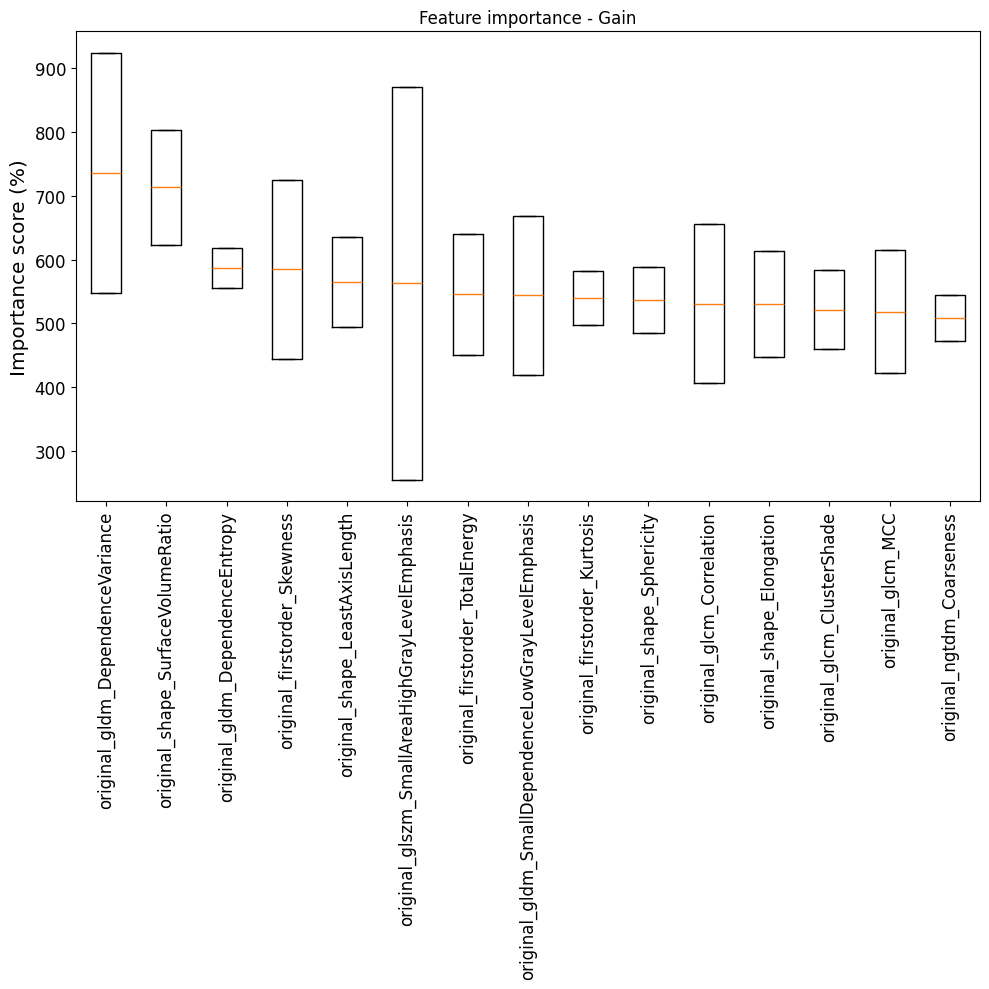

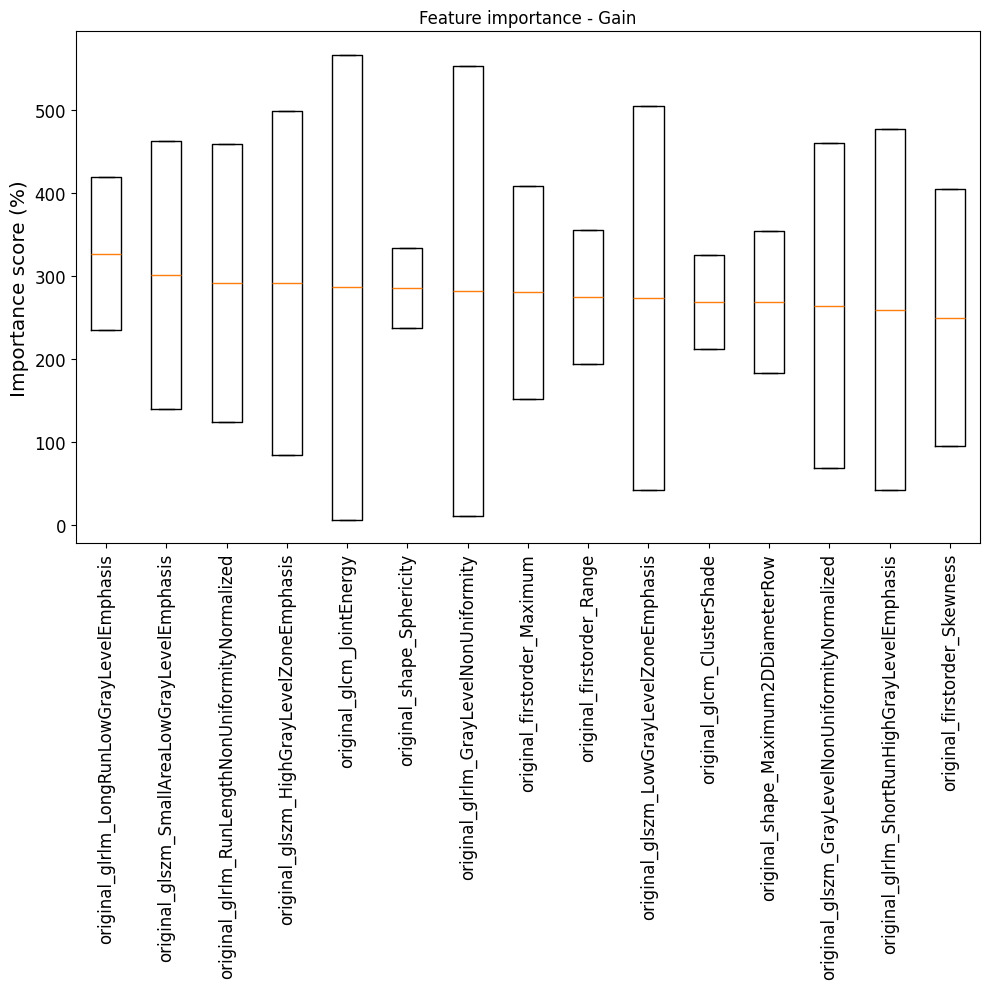

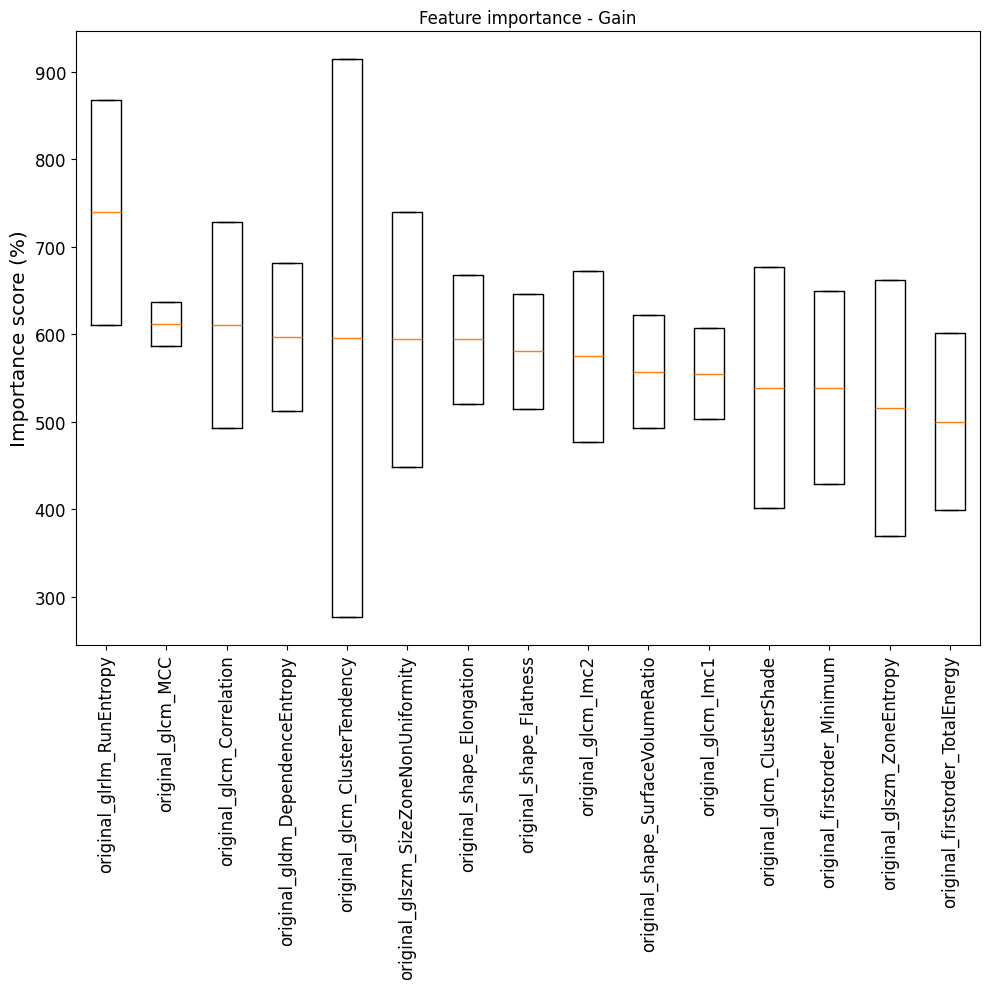

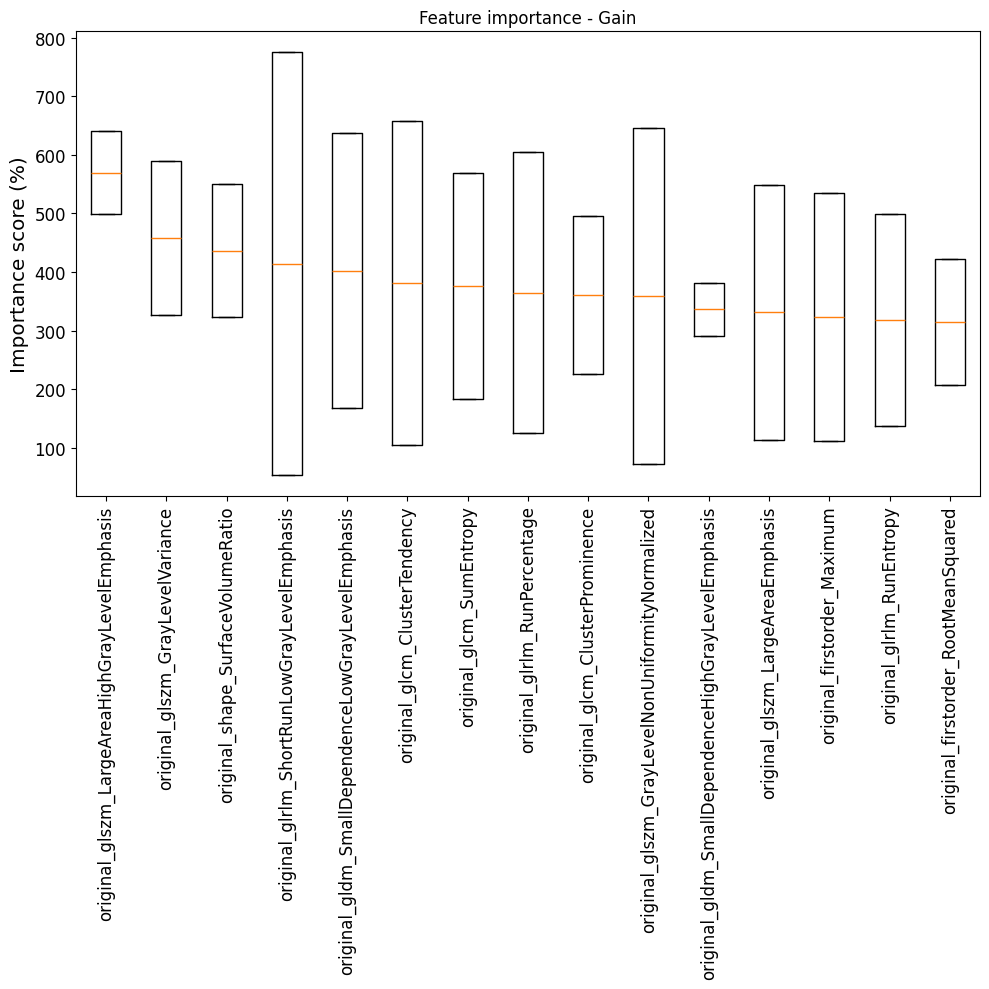

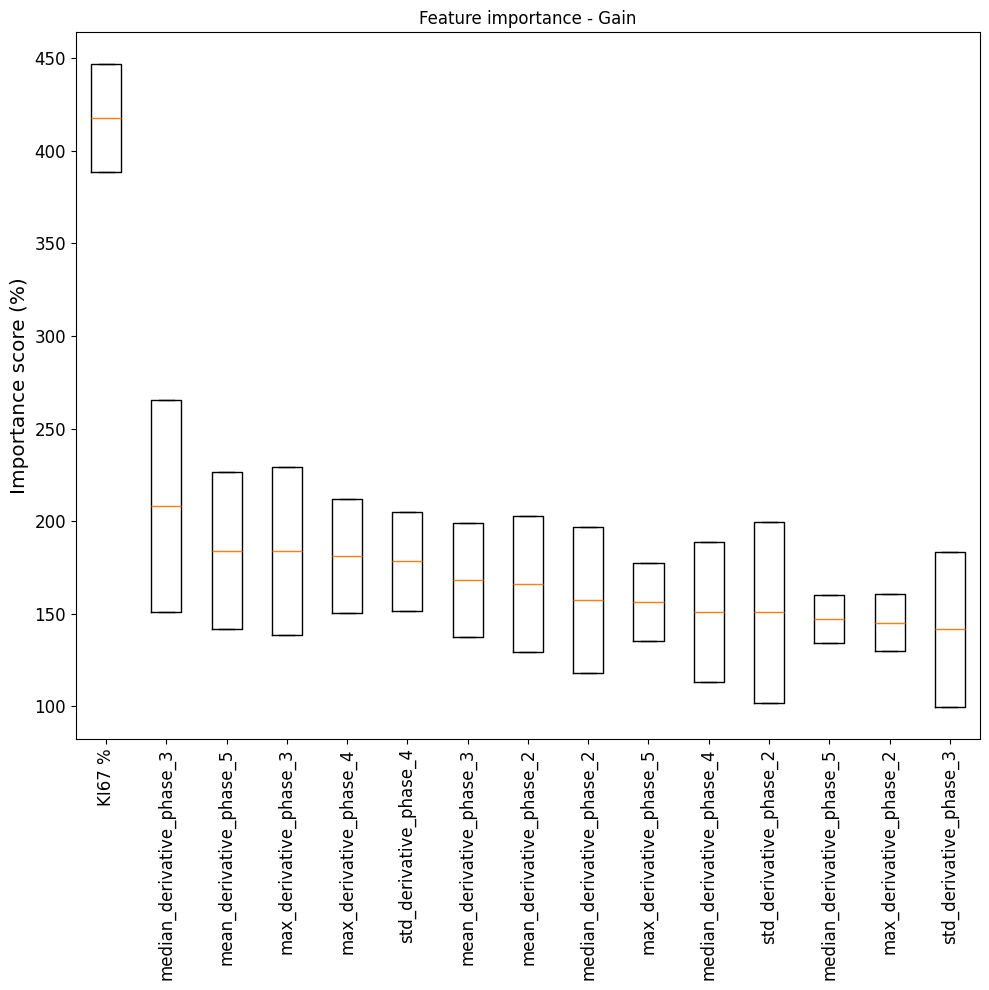

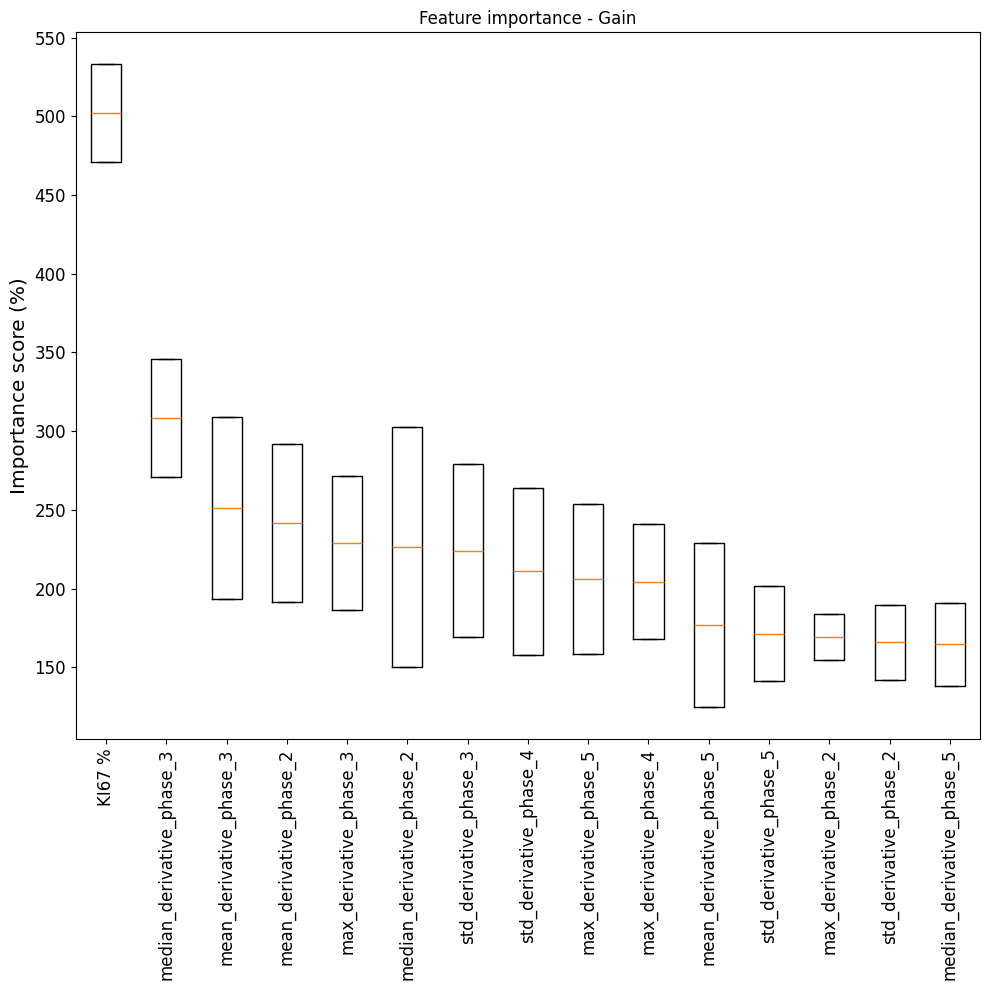

In [13]:
results = {}

# Configurazione per feature importance
OUTPUT_DIR = Path("/Users/francesco/Tesi/BC-ML4/src/modelli_singoli/XGBoost/boxplot")

# ============================================================================
# RADIOMICHE - ORIGINALI
# ============================================================================

# ============================
# DUKE_ER (radiomic originale)
# ============================
print("\n" + "="*80)
print("TRAINING DUKE_ER (RADIOMIC)")
print("="*80)

results["DUKE_ER"] = train(
    FILE_PATH / "duke_lesions.csv",
    "duke_lesions",
    dataset_type="duke",
    tipo_fold=TIPO_FOLD,
    balance_test=BALANCE_TEST
)

# Feature Importance DUKE_ER (media sui 5 fold)
print("\n>>> FEATURE IMPORTANCE DUKE_ER (media su 5 fold)")
fi_df = get_feature_importance_from_folds(
    results["DUKE_ER"]["X"],
    results["DUKE_ER"]["y"],
    results["DUKE_ER"]["splits"],
    results["DUKE_ER"]["best_params"],
    importance_type='gain'
)
save_feature_importance(fi_df, OUTPUT_DIR / "feature_importance_DUKE_ER.csv", top_n=20)

# Plot Feature Importance DUKE_ER
print("\n>>> PLOT FEATURE IMPORTANCE DUKE_ER")
fi_dict_duke = get_feature_importance_dict_from_folds(
    results["DUKE_ER"]["X"],
    results["DUKE_ER"]["y"],
    results["DUKE_ER"]["splits"],
    results["DUKE_ER"]["best_params"],
    importance_type='gain'
)
plot_aggregated_feature_importance(
    fi_dict_duke,
    n_features=15,
    filepath=OUTPUT_DIR / "feature_importance_DUKE_ER_boxplot.png"
)

# ============================
# AMBL_ER (radiomic originale)
# ============================
print("\n" + "="*80)
print("TRAINING AMBL_ER (RADIOMIC)")
print("="*80)

results["AMBL_ER"] = train(
    FILE_PATH / "ambl_lesions_binary.csv",
    "ambl_lesions_binary",
    dataset_type="ambl",
    tipo_fold=TIPO_FOLD,
    balance_test=BALANCE_TEST
)

# Feature Importance AMBL_ER (media sui 5 fold)
print("\n>>> FEATURE IMPORTANCE AMBL_ER (media su 5 fold)")
fi_df = get_feature_importance_from_folds(
    results["AMBL_ER"]["X"],
    results["AMBL_ER"]["y"],
    results["AMBL_ER"]["splits"],
    results["AMBL_ER"]["best_params"],
    importance_type='gain'
)
save_feature_importance(fi_df, OUTPUT_DIR / "feature_importance_AMBL_ER.csv", top_n=20)

# Plot Feature Importance AMBL_ER
print("\n>>> PLOT FEATURE IMPORTANCE AMBL_ER")
fi_dict_ambl = get_feature_importance_dict_from_folds(
    results["AMBL_ER"]["X"],
    results["AMBL_ER"]["y"],
    results["AMBL_ER"]["splits"],
    results["AMBL_ER"]["best_params"],
    importance_type='gain'
)
plot_aggregated_feature_importance(
    fi_dict_ambl,
    n_features=15,
    filepath=OUTPUT_DIR / "feature_importance_AMBL_ER_boxplot.png"
)

# ============================================================================
# RADIOMICHE - MEDSAM
# ============================================================================

# ============================
# DUKE_medsam_ER (radiomic medsam)
# ============================
print("\n" + "="*80)
print("TRAINING DUKE_medsam_ER (RADIOMIC MEDSAM)")
print("="*80)

results["DUKE_medsam_ER"] = train(
    FILE_PATH / "duke_lesions_radiomic_medsam.csv",
    "duke_lesions_radiomic_medsam",
    dataset_type="duke_medsam",
    tipo_fold=TIPO_FOLD,
    balance_test=BALANCE_TEST
)

# Feature Importance DUKE_medsam_ER (media sui 5 fold)
print("\n>>> FEATURE IMPORTANCE DUKE_medsam_ER (media su 5 fold)")
fi_df = get_feature_importance_from_folds(
    results["DUKE_medsam_ER"]["X"],
    results["DUKE_medsam_ER"]["y"],
    results["DUKE_medsam_ER"]["splits"],
    results["DUKE_medsam_ER"]["best_params"],
    importance_type='gain'
)
save_feature_importance(fi_df, OUTPUT_DIR / "feature_importance_DUKE_medsam_ER.csv", top_n=20)

# Plot Feature Importance DUKE_medsam_ER
print("\n>>> PLOT FEATURE IMPORTANCE DUKE_medsam_ER")
fi_dict_duke_medsam = get_feature_importance_dict_from_folds(
    results["DUKE_medsam_ER"]["X"],
    results["DUKE_medsam_ER"]["y"],
    results["DUKE_medsam_ER"]["splits"],
    results["DUKE_medsam_ER"]["best_params"],
    importance_type='gain'
)
plot_aggregated_feature_importance(
    fi_dict_duke_medsam,
    n_features=15,
    filepath=OUTPUT_DIR / "feature_importance_DUKE_medsam_ER_boxplot.png"
)

# ============================
# AMBL_medsam_ER (radiomic medsam)
# ============================
print("\n" + "="*80)
print("TRAINING AMBL_medsam_ER (RADIOMIC MEDSAM)")
print("="*80)

results["AMBL_medsam_ER"] = train(
    FILE_PATH / "ambl_lesions_radiomic_medsam_binary.csv",
    "ambl_lesions_radiomic_medsam_binary",
    dataset_type="ambl_medsam",
    tipo_fold=TIPO_FOLD,
    balance_test=BALANCE_TEST
)

# Feature Importance AMBL_medsam_ER (media sui 5 fold)
print("\n>>> FEATURE IMPORTANCE AMBL_medsam_ER (media su 5 fold)")
fi_df = get_feature_importance_from_folds(
    results["AMBL_medsam_ER"]["X"],
    results["AMBL_medsam_ER"]["y"],
    results["AMBL_medsam_ER"]["splits"],
    results["AMBL_medsam_ER"]["best_params"],
    importance_type='gain'
)
save_feature_importance(fi_df, OUTPUT_DIR / "feature_importance_AMBL_medsam_ER.csv", top_n=20)

# Plot Feature Importance AMBL_medsam_ER
print("\n>>> PLOT FEATURE IMPORTANCE AMBL_medsam_ER")
fi_dict_ambl_medsam = get_feature_importance_dict_from_folds(
    results["AMBL_medsam_ER"]["X"],
    results["AMBL_medsam_ER"]["y"],
    results["AMBL_medsam_ER"]["splits"],
    results["AMBL_medsam_ER"]["best_params"],
    importance_type='gain'
)
plot_aggregated_feature_importance(
    fi_dict_ambl_medsam,
    n_features=15,
    filepath=OUTPUT_DIR / "feature_importance_AMBL_medsam_ER_boxplot.png"
)

# ============================================================================
# DYNAMIC - ORIGINALI
# ============================================================================

# ============================
# AMBL_dynamic_ER (dynamic originale)
# ============================
print("\n" + "="*80)
print("TRAINING AMBL_dynamic_ER (DYNAMIC)")
print("="*80)

results["AMBL_dynamic_ER"] = train(
    FILE_PATH / "ambl_original_dynamic_binary.csv",
    "ambl_lesions_dynamic_binary",
    dataset_type="ambl",
    tipo_fold=TIPO_FOLD,
    balance_test=BALANCE_TEST
)

# Feature Importance AMBL_dynamic_ER (media sui 5 fold)
print("\n>>> FEATURE IMPORTANCE AMBL_dynamic_ER (media su 5 fold)")
fi_df = get_feature_importance_from_folds(
    results["AMBL_dynamic_ER"]["X"],
    results["AMBL_dynamic_ER"]["y"],
    results["AMBL_dynamic_ER"]["splits"],
    results["AMBL_dynamic_ER"]["best_params"],
    importance_type='gain'
)
save_feature_importance(fi_df, OUTPUT_DIR / "feature_importance_AMBL_dynamic_ER.csv", top_n=20)

# Plot Feature Importance AMBL_dynamic_ER
print("\n>>> PLOT FEATURE IMPORTANCE AMBL_dynamic_ER")
fi_dict_ambl_dynamic = get_feature_importance_dict_from_folds(
    results["AMBL_dynamic_ER"]["X"],
    results["AMBL_dynamic_ER"]["y"],
    results["AMBL_dynamic_ER"]["splits"],
    results["AMBL_dynamic_ER"]["best_params"],
    importance_type='gain'
)
plot_aggregated_feature_importance(
    fi_dict_ambl_dynamic,
    n_features=15,
    filepath=OUTPUT_DIR / "feature_importance_AMBL_dynamic_ER_boxplot.png"
)

# ============================================================================
# DYNAMIC - MEDSAM
# ============================================================================

# ============================
# AMBL_dynamic_medsam_ER (dynamic medsam)
# ============================
print("\n" + "="*80)
print("TRAINING AMBL_dynamic_medsam_ER (DYNAMIC MEDSAM)")
print("="*80)

results["AMBL_dynamic_medsam_ER"] = train(
    FILE_PATH / "ambl_medsam_dynamic_binary.csv",
    "ambl_lesions_dynamic_medsam_binary",
    dataset_type="ambl_medsam",
    tipo_fold=TIPO_FOLD,
    balance_test=BALANCE_TEST
)

# Feature Importance AMBL_dynamic_medsam_ER (media sui 5 fold)
print("\n>>> FEATURE IMPORTANCE AMBL_dynamic_medsam_ER (media su 5 fold)")
fi_df = get_feature_importance_from_folds(
    results["AMBL_dynamic_medsam_ER"]["X"],
    results["AMBL_dynamic_medsam_ER"]["y"],
    results["AMBL_dynamic_medsam_ER"]["splits"],
    results["AMBL_dynamic_medsam_ER"]["best_params"],
    importance_type='gain'
)
save_feature_importance(fi_df, OUTPUT_DIR / "feature_importance_AMBL_dynamic_medsam_ER.csv", top_n=20)

# Plot Feature Importance AMBL_dynamic_medsam_ER
print("\n>>> PLOT FEATURE IMPORTANCE AMBL_dynamic_medsam_ER")
fi_dict_ambl_dynamic_medsam = get_feature_importance_dict_from_folds(
    results["AMBL_dynamic_medsam_ER"]["X"],
    results["AMBL_dynamic_medsam_ER"]["y"],
    results["AMBL_dynamic_medsam_ER"]["splits"],
    results["AMBL_dynamic_medsam_ER"]["best_params"],
    importance_type='gain'
)
plot_aggregated_feature_importance(
    fi_dict_ambl_dynamic_medsam,
    n_features=15,
    filepath=OUTPUT_DIR / "feature_importance_AMBL_dynamic_medsam_ER_boxplot.png"
)



# ============================================================================
# RIEPILOGO FINALE
# ============================================================================
print("\n" + "="*80)
print("RIEPILOGO FINALE")
print("="*80)

for name, res in results.items():
    print(f"\nDataset: {res['dataset']}")
    print("-" * 80)
    print(f" Target: {res['target']}")
    print(f"  F1-score         = {res['mean_f1']:.3f}  ±  {res['std_f1']:.3f}")
    print(f"  Accuracy         = {res['mean_acc']:.3f}  ±  {res['std_acc']:.3f}")
    print(f"  Balanced Acc     = {res['mean_bal_acc']:.3f}  ±  {res['std_bal_acc']:.3f}") 
    print(f"  AUC              = {res['mean_auc']:.3f}  ±  {res['std_auc']:.3f}")

# ============================================================================
# Salvataggio risultati ER in CSV
# ============================================================================
rows = []

for name, res in results.items():
    row = {
        "experiment": name,
        "dataset": res["dataset"],
        "target": res["target"],
        "mean_f1": round(res["mean_f1"], 3),
        "std_f1": round(res["std_f1"], 3),
        "mean_accuracy": round(res["mean_acc"], 3),
        "std_accuracy": round(res["std_acc"], 3),
        "mean_balanced_accuracy": round(res["mean_bal_acc"], 3),
        "std_balanced_accuracy": round(res["std_bal_acc"], 3),
        "mean_auc": round(res["mean_auc"], 3),
        "std_auc": round(res["std_auc"], 3)
    }
    rows.append(row)

df_er = pd.DataFrame(rows)
df_er = df_er.round(3)
output_path = "/Users/francesco/Tesi/BC-ML4/src/modelli_singoli/XGBoost/xgb_singolo.csv"
df_er.to_csv(output_path, index=False, float_format="%.3f")

print(f"\nRisultati ER salvati in:\n{output_path}")

# Cross-Validation tra dataset

In [14]:
def cross_validation(train_csv, train_name, train_type, test_csv, test_name, test_type, best_params, balance_test=False):
    print("\n" + "="*80)
    print("CROSS-DATASET VALIDATION")
    print("="*80)
    print(f"TRAIN: {train_name}")
    print(f"TEST : {test_name}")
    print("="*80)

    # Carico il csv di Training
    df_train = load_dataset(train_csv, train_name)
    target_train = TARGET_MAP[train_type]
    df_train, y_train = select_target(df_train, target_train)
    X_train, _ = build_features_and_groups(df_train, target_train, train_type)

    # Carico il csv di Testing
    df_test = load_dataset(test_csv, test_name)
    target_test = TARGET_MAP[test_type]
    df_test, y_test = select_target(df_test, target_test)
    X_test, _ = build_features_and_groups(df_test, target_test, test_type)

    # Allineamento feature
    common_cols = X_train.columns.intersection(X_test.columns)
    X_train = X_train[common_cols]
    X_test  = X_test[common_cols]

    print(f"\nFeature comuni utilizzate: {len(common_cols)}")

    # Alleno il modello sul TRAIN set
    model = get_model(best_params)
    model.fit(X_train, y_train)

    # ora test_idx punta al test set
    test_idx = np.arange(len(X_test))
    
    # Bilanciamento opzionale del test set
    if balance_test:
        # Creo uno split fittizio per riutilizzare la funzione di bilanciamento
        dummy_train = np.array([])  # Train vuoto, non serve
        splits = [(dummy_train, test_idx)]
        splits = balance_test_sets(splits, y_test)
        _, test_idx = splits[0]

    # Predizioni sul test set (bilanciato o meno)
    y_pred = model.predict(X_test.iloc[test_idx])
    y_prob = model.predict_proba(X_test.iloc[test_idx])[:,1]
    y_test_final = y_test.iloc[test_idx]

    # Metriche
    f1 = f1_score(y_test_final, y_pred, zero_division=0)
    acc = accuracy_score(y_test_final, y_pred)
    bal_acc = balanced_accuracy_score(y_test_final, y_pred)
    auc = roc_auc_score(y_test_final, y_prob)

    print("\n" + "-"*80)
    print("RISULTATI CROSS-DATASET")
    print("-"*80)
    print(f" F1-score          : {f1:.4f}")
    print(f" Accuracy          : {acc:.4f}")
    print(f" Balanced Accuracy : {bal_acc:.4f}")
    print(f" ROC-AUC           : {auc:.4f}")

    print("\nCONFUSION MATRIX")
    cm = confusion_matrix(y_test_final, y_pred)
    print(cm)

    print("\nCLASSIFICATION REPORT")
    print(classification_report(y_test_final, y_pred, zero_division=0))

    return {
        "train": train_name,
        "test": test_name,
        "balance_test": balance_test,
        "f1": f1,
        "acc": acc,
        "bal_acc": bal_acc,
        "auc": auc,
        "cm": cm
    }

In [15]:
def save_cross_results_to_csv(cross_results, output_path):
    """
    Salva (o aggiunge) i risultati della cross-dataset validation in CSV.
    """

    rows = []

    for exp_name, res in cross_results.items():
        row = {
            "experiment": exp_name,
            "train_dataset": res.get("train"),
            "test_dataset": res.get("test"),
            "balance_test": res.get("balance_test"),
            "f1": round(res.get("f1"), 3),
            "accuracy": round(res.get("acc"), 3),
            "balanced_accuracy": round(res.get("bal_acc"), 3),
            "auc": round(res.get("auc"), 3)
        }
        rows.append(row)

    df = pd.DataFrame(rows)

    file_exists = Path(output_path).exists()

    df.to_csv(
        output_path,
        mode="a" if file_exists else "w",
        header=not file_exists,
        index=False,
        float_format="%.3f"
    )

    print(f"\n Risultati cross-dataset aggiunti in:")
    print(output_path)

    return df

# Esecuzione CV

In [16]:
cross_results = {}

# Prendo i best params dalle CV intra-dataset
best_params_ambl = results["AMBL_ER"]["best_params"]
best_params_duke = results["DUKE_ER"]["best_params"]
best_params_ambl_medsam = results["AMBL_medsam_ER"]["best_params"]
best_params_duke_medsam = results["DUKE_medsam_ER"]["best_params"]

# ================================
# 1. AMBL → DUKE
# ================================
cross_results["AMBL_to_DUKE"] = cross_validation(
    FILE_PATH / "ambl_lesions_binary.csv",
    "ambl_lesions_binary",
    "ambl",
    FILE_PATH / "duke_lesions.csv",
    "duke_lesions",
    "duke",
    best_params_ambl,
    balance_test=BALANCE_TEST
)

# ================================
# 2. DUKE → AMBL
# ================================
cross_results["DUKE_to_AMBL"] = cross_validation(
    FILE_PATH / "duke_lesions.csv",
    "duke_lesions",
    "duke",
    FILE_PATH / "ambl_lesions_binary.csv",
    "ambl_lesions_binary",
    "ambl",
    best_params_duke,
    balance_test=BALANCE_TEST
)

# ================================
# 3. AMBL_medsam → DUKE_medsam
# ================================
cross_results["AMBL_medsam_to_DUKE_medsam"] = cross_validation(
    FILE_PATH / "ambl_lesions_radiomic_medsam_binary.csv",
    "ambl_lesions_radiomic_medsam_binary",
    "ambl_medsam",
    FILE_PATH / "duke_lesions_radiomic_medsam.csv",
    "duke_lesions_radiomic_medsam",
    "duke_medsam",
    best_params_ambl_medsam,
    balance_test=BALANCE_TEST
)

# ================================
# 4. DUKE_medsam → AMBL_medsam
# ================================
cross_results["DUKE_medsam_to_AMBL_medsam"] = cross_validation(
    FILE_PATH / "duke_lesions_radiomic_medsam.csv",
    "duke_lesions_radiomic_medsam",
    "duke_medsam",
    FILE_PATH / "ambl_lesions_radiomic_medsam_binary.csv",
    "ambl_lesions_radiomic_medsam_binary",
    "ambl_medsam",
    best_params_duke_medsam,
    balance_test=BALANCE_TEST
)

# Salva i risultati
save_cross_results_to_csv(
    cross_results,
    "/Users/francesco/Tesi/BC-ML4/src/modelli_singoli/XGBoost/cross_validation_xgb_complete.csv"
)


CROSS-DATASET VALIDATION
TRAIN: ambl_lesions_binary
TEST : duke_lesions
  Shape: (82, 109)
  Colonne: 109
  Righe: 82
  Patient ID  ER [SII]  PR [SII]  HER2 [SII]  original_shape_Elongation  \
0   AMBL-001         0         0           0                   0.528082   
1   AMBL-001         0         0           0                   0.336182   
2   AMBL-003         0         0           0                   0.563923   
3   AMBL-005         1         1           0                   0.761755   
4   AMBL-007         1         0           0                   0.557584   

   original_shape_Flatness  original_shape_LeastAxisLength  \
0                 0.375975                        8.551139   
1                 0.293785                        7.651833   
2                 0.394181                        8.781372   
3                 0.641036                       20.245467   
4                 0.366074                       18.597143   

   original_shape_MajorAxisLength  original_shape_Maximum

,experiment,train_dataset,test_dataset,balance_test,f1,accuracy,balanced_accuracy,auc
0,AMBL_to_DUKE,ambl_lesions_binary,duke_lesions,True,0.612,0.484,0.484,0.503
1,DUKE_to_AMBL,duke_lesions,ambl_lesions_binary,True,0.548,0.406,0.406,0.382
2,AMBL_medsam_to_DUKE_medsam,ambl_lesions_radiomic_medsam_binary,duke_lesions_radiomic_medsam,True,0.607,0.500,0.500,0.520
3,DUKE_medsam_to_AMBL_medsam,duke_lesions_radiomic_medsam,ambl_lesions_radiomic_medsam_binary,True,0.674,0.531,0.531,0.585
